## Import Library

In [3]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, PowerTransformer, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
import xgboost as xgb
import catboost as cb

import optuna
from sklearn.metrics import classification_report, f1_score

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Load

In [4]:
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')

df_master = pd.merge(df_orders, df_customers, on='customer_id', how='left')
df_master = pd.merge(df_master, df_reviews, on='order_id', how='left')
df_master = pd.merge(df_master, df_payments, on='order_id', how='left')
df_master = pd.merge(df_master, df_items, on='order_id', how='left')
df_master = pd.merge(df_master, df_products, on='product_id', how='left')

df_master.head()
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  review_id                     

## Cleaning Data

In [5]:
for col in df_master.columns:
    unique_vals = df_master[col].nunique(dropna=False)
    if unique_vals <= 30:
        print(f"{col} ({unique_vals} unique values)")
        print(df_master[col].value_counts(dropna=False))
        print("\n")

order_status (8 unique values)
order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


customer_state (27 unique values)
customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
PE     1906
CE     1565
MT     1132
PA     1129
MS      862
MA      856
PB      644
PI      576
RN      574
AL      464
SE      403
TO      340
RO      292
AM      173
AC       95
AP       84
RR       52
Name: count, dtype: int64


review_score (6 unique values)
review_score
5.0    66343
4.0    22319
1.0    15428
3.0     9894
2.0     4162
NaN      997
Name: count, dtype: int64


payment_sequential (30 unique values)
payment_sequential
1.0     113999
2.0       3415
3.0        658
4.0        322
5.0        194
6.0        136
7.0         94
8.0         63
9.0         51
10.0     

In [6]:
cols_to_drop = ['order_id', 'customer_id', 'customer_unique_id', 'review_id', 'product_id', 'seller_id']
df_master = df_master.drop(columns=cols_to_drop, axis=1)

mandatory_cols = df_master.columns.drop(['review_comment_title', 'review_comment_message'])
total_initial_rows = len(df_master)

df_clean = df_master.dropna(subset=mandatory_cols)
total_cleaned_rows = len(df_clean)
missing_pct = ((total_initial_rows - total_cleaned_rows) / total_initial_rows) * 100

print(f"Total baris awal: {total_initial_rows}")
print(f"Sisa baris setelah drop (teks dikecualikan): {total_cleaned_rows}")
print(f"Persentase data yang terbuang: {missing_pct:.2f} %")

df_master = df_clean.reset_index(drop=True)
df_master.info()

Total baris awal: 119143
Sisa baris setelah drop (teks dikecualikan): 113216
Persentase data yang terbuang: 4.97 %
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113216 entries, 0 to 113215
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_status                   113216 non-null  object 
 1   order_purchase_timestamp       113216 non-null  object 
 2   order_approved_at              113216 non-null  object 
 3   order_delivered_carrier_date   113216 non-null  object 
 4   order_delivered_customer_date  113216 non-null  object 
 5   order_estimated_delivery_date  113216 non-null  object 
 6   customer_zip_code_prefix       113216 non-null  int64  
 7   customer_city                  113216 non-null  object 
 8   customer_state                 113216 non-null  object 
 9   review_score                   113216 non-null  float64
 10  review_comment_title           13502 

## Check Correlation (linear)

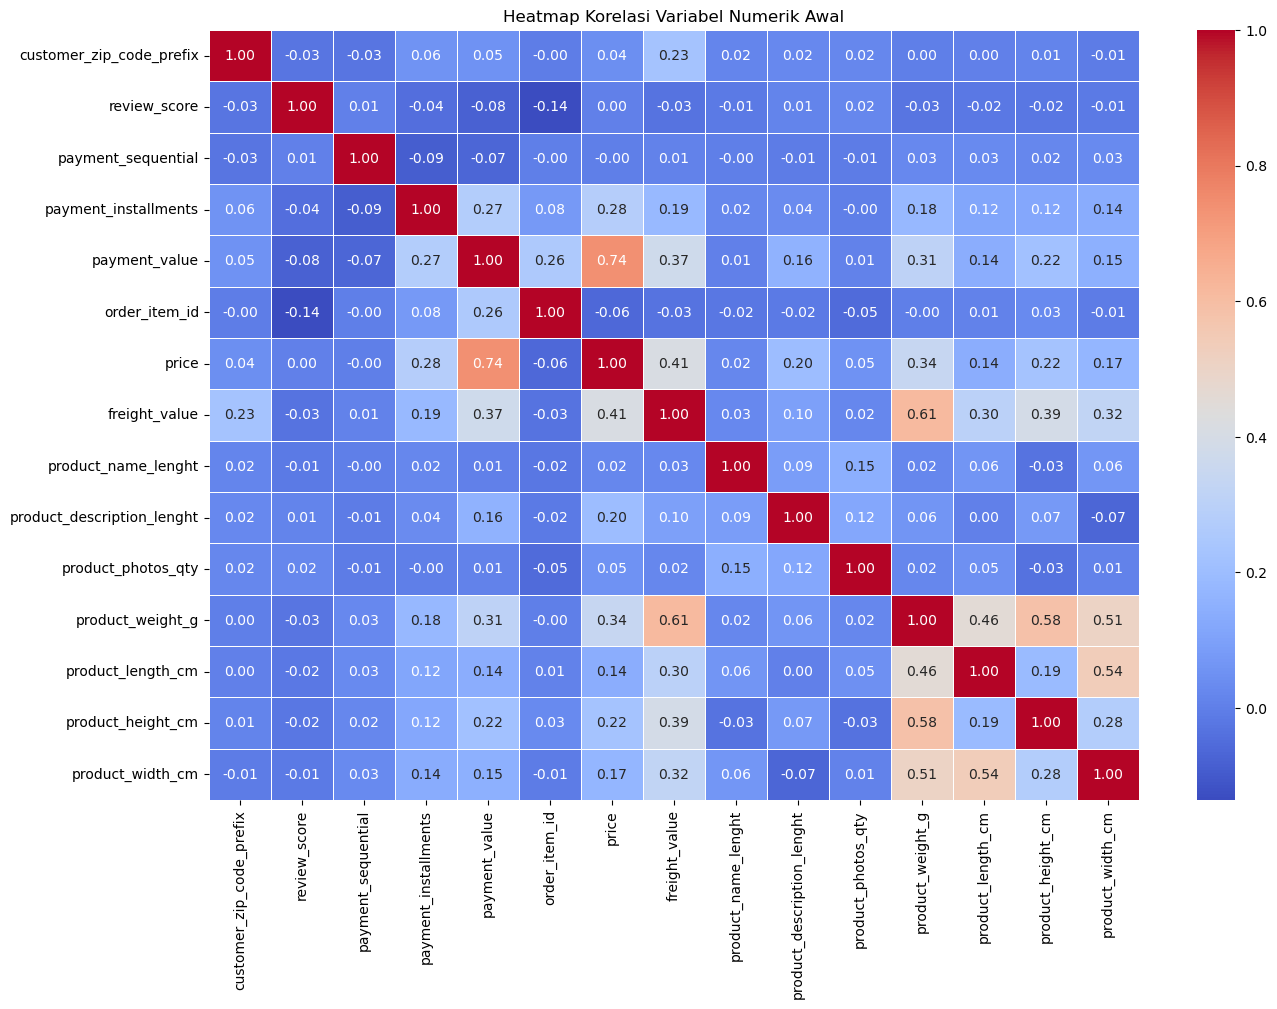

In [7]:
def plot_correlation_heatmap(df, title):
    numeric_cols = df.select_dtypes(include='number')
    corr_matrix = numeric_cols.corr()
    
    plt.figure(figsize=(15, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(title)
    plt.show()

plot_correlation_heatmap(df_master, 'Heatmap Korelasi Variabel Numerik Awal')

## Feature Engineering

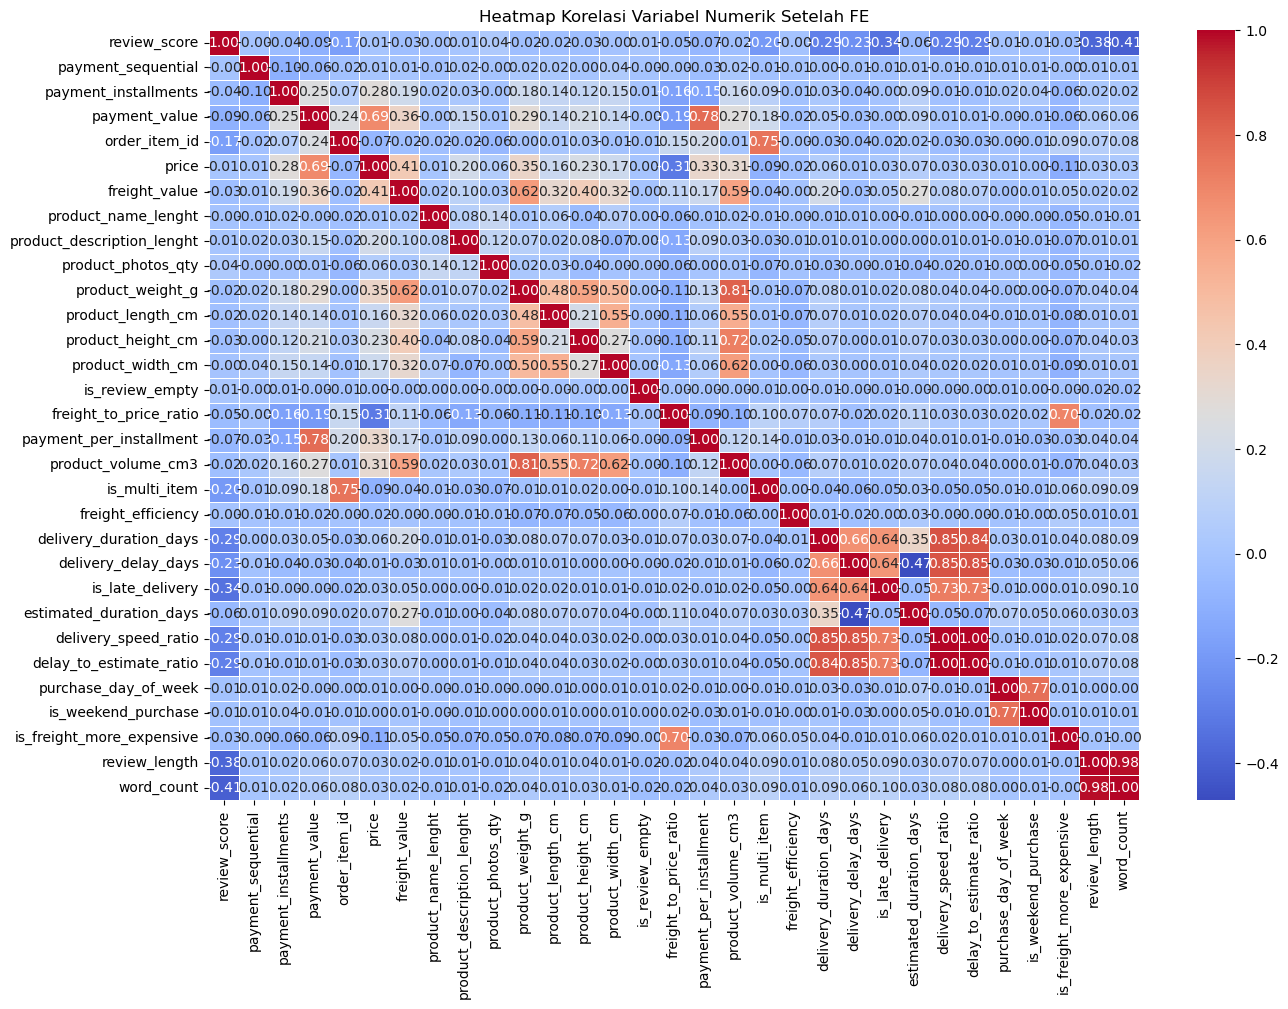

In [8]:
date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
    'review_creation_date', 'review_answer_timestamp', 'shipping_limit_date'
]

for col in date_columns:
    df_master[col] = pd.to_datetime(df_master[col])

int_columns = [
    'review_score', 'payment_sequential', 'payment_installments', 
    'order_item_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'
]

for col in int_columns:
    df_master[col] = df_master[col].astype('int64')

df_master = df_master.dropna(subset=['review_comment_message']).reset_index(drop=True)

df_master['review_comment_title'] = df_master['review_comment_title'].fillna('')
df_master['combined_text'] = (df_master['review_comment_title'] + " " + df_master['review_comment_message']).str.strip()

df_master['is_review_empty'] = (df_master['combined_text'] == '').astype('Int64')
df_master['freight_to_price_ratio'] = df_master['freight_value'] / (df_master['price'] + 1)
df_master['payment_per_installment'] = df_master['payment_value'] / df_master['payment_installments'].clip(lower=1)
df_master['product_volume_cm3'] = df_master['product_length_cm'] * df_master['product_height_cm'] * df_master['product_width_cm']
df_master['is_multi_item'] = (df_master['order_item_id'] > 1).astype('Int64')
df_master['freight_efficiency'] = df_master['freight_value'] / (df_master['product_weight_g'] + 1)

df_master['delivery_duration_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days
df_master['delivery_delay_days'] = (df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']).dt.days
df_master['is_late_delivery'] = (df_master['delivery_delay_days'] > 0).astype('Int64')
df_master['estimated_duration_days'] = (df_master['order_estimated_delivery_date'] - df_master['order_purchase_timestamp']).dt.days

df_master['delivery_speed_ratio'] = df_master['delivery_duration_days'] / (df_master['estimated_duration_days'] + 1)
df_master['delay_to_estimate_ratio'] = df_master['delivery_delay_days'] / (df_master['estimated_duration_days'] + 1)

df_master['purchase_day_of_week'] = df_master['order_purchase_timestamp'].dt.dayofweek
df_master['is_weekend_purchase'] = df_master['purchase_day_of_week'].isin([5, 6]).astype('Int64')
df_master['is_freight_more_expensive'] = (df_master['freight_value'] > df_master['price']).astype('Int64')

df_master['review_length'] = df_master['review_comment_message'].astype(str).apply(len)
df_master['word_count'] = df_master['review_comment_message'].astype(str).apply(lambda x: len(x.split()))

df_master = df_master.sort_values(by='order_purchase_timestamp').reset_index(drop=True)

datetime_cols = df_master.select_dtypes(include=['datetime64[ns]']).columns.tolist()
text_cols_to_drop = ['order_status', 'customer_zip_code_prefix', 'customer_city']
cols_to_drop_final = datetime_cols + text_cols_to_drop

df_master = df_master.drop(columns=cols_to_drop_final)

plot_correlation_heatmap(df_master, 'Heatmap Korelasi Variabel Numerik Setelah FE')

## Split and Mapping

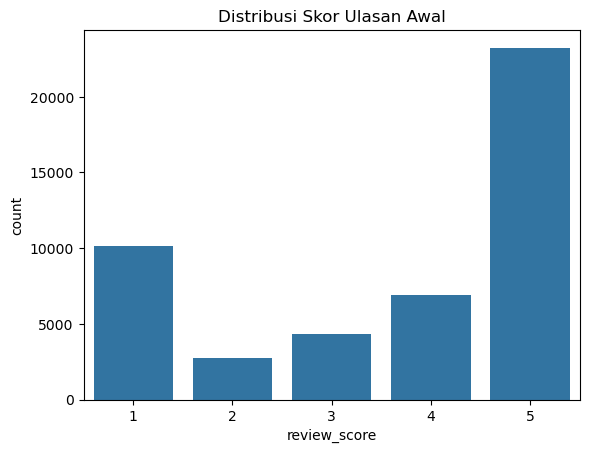

In [9]:
sns.countplot(x=df_master['review_score'])
plt.title('Distribusi Skor Ulasan Awal')
plt.show()

In [10]:
x_features = df_master.drop(columns=['review_score'])
y_original = df_master['review_score'].astype(int) - 1

def map_to_sentiment(score):
    if score in [0, 1]: return 0 
    elif score == 2: return 1 
    elif score in [3, 4]: return 2 

y_sentiment = y_original.apply(map_to_sentiment)

x_train, x_test, y_train, y_test = train_test_split(
    x_features, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

## EDA (Outlier and Skew Check)

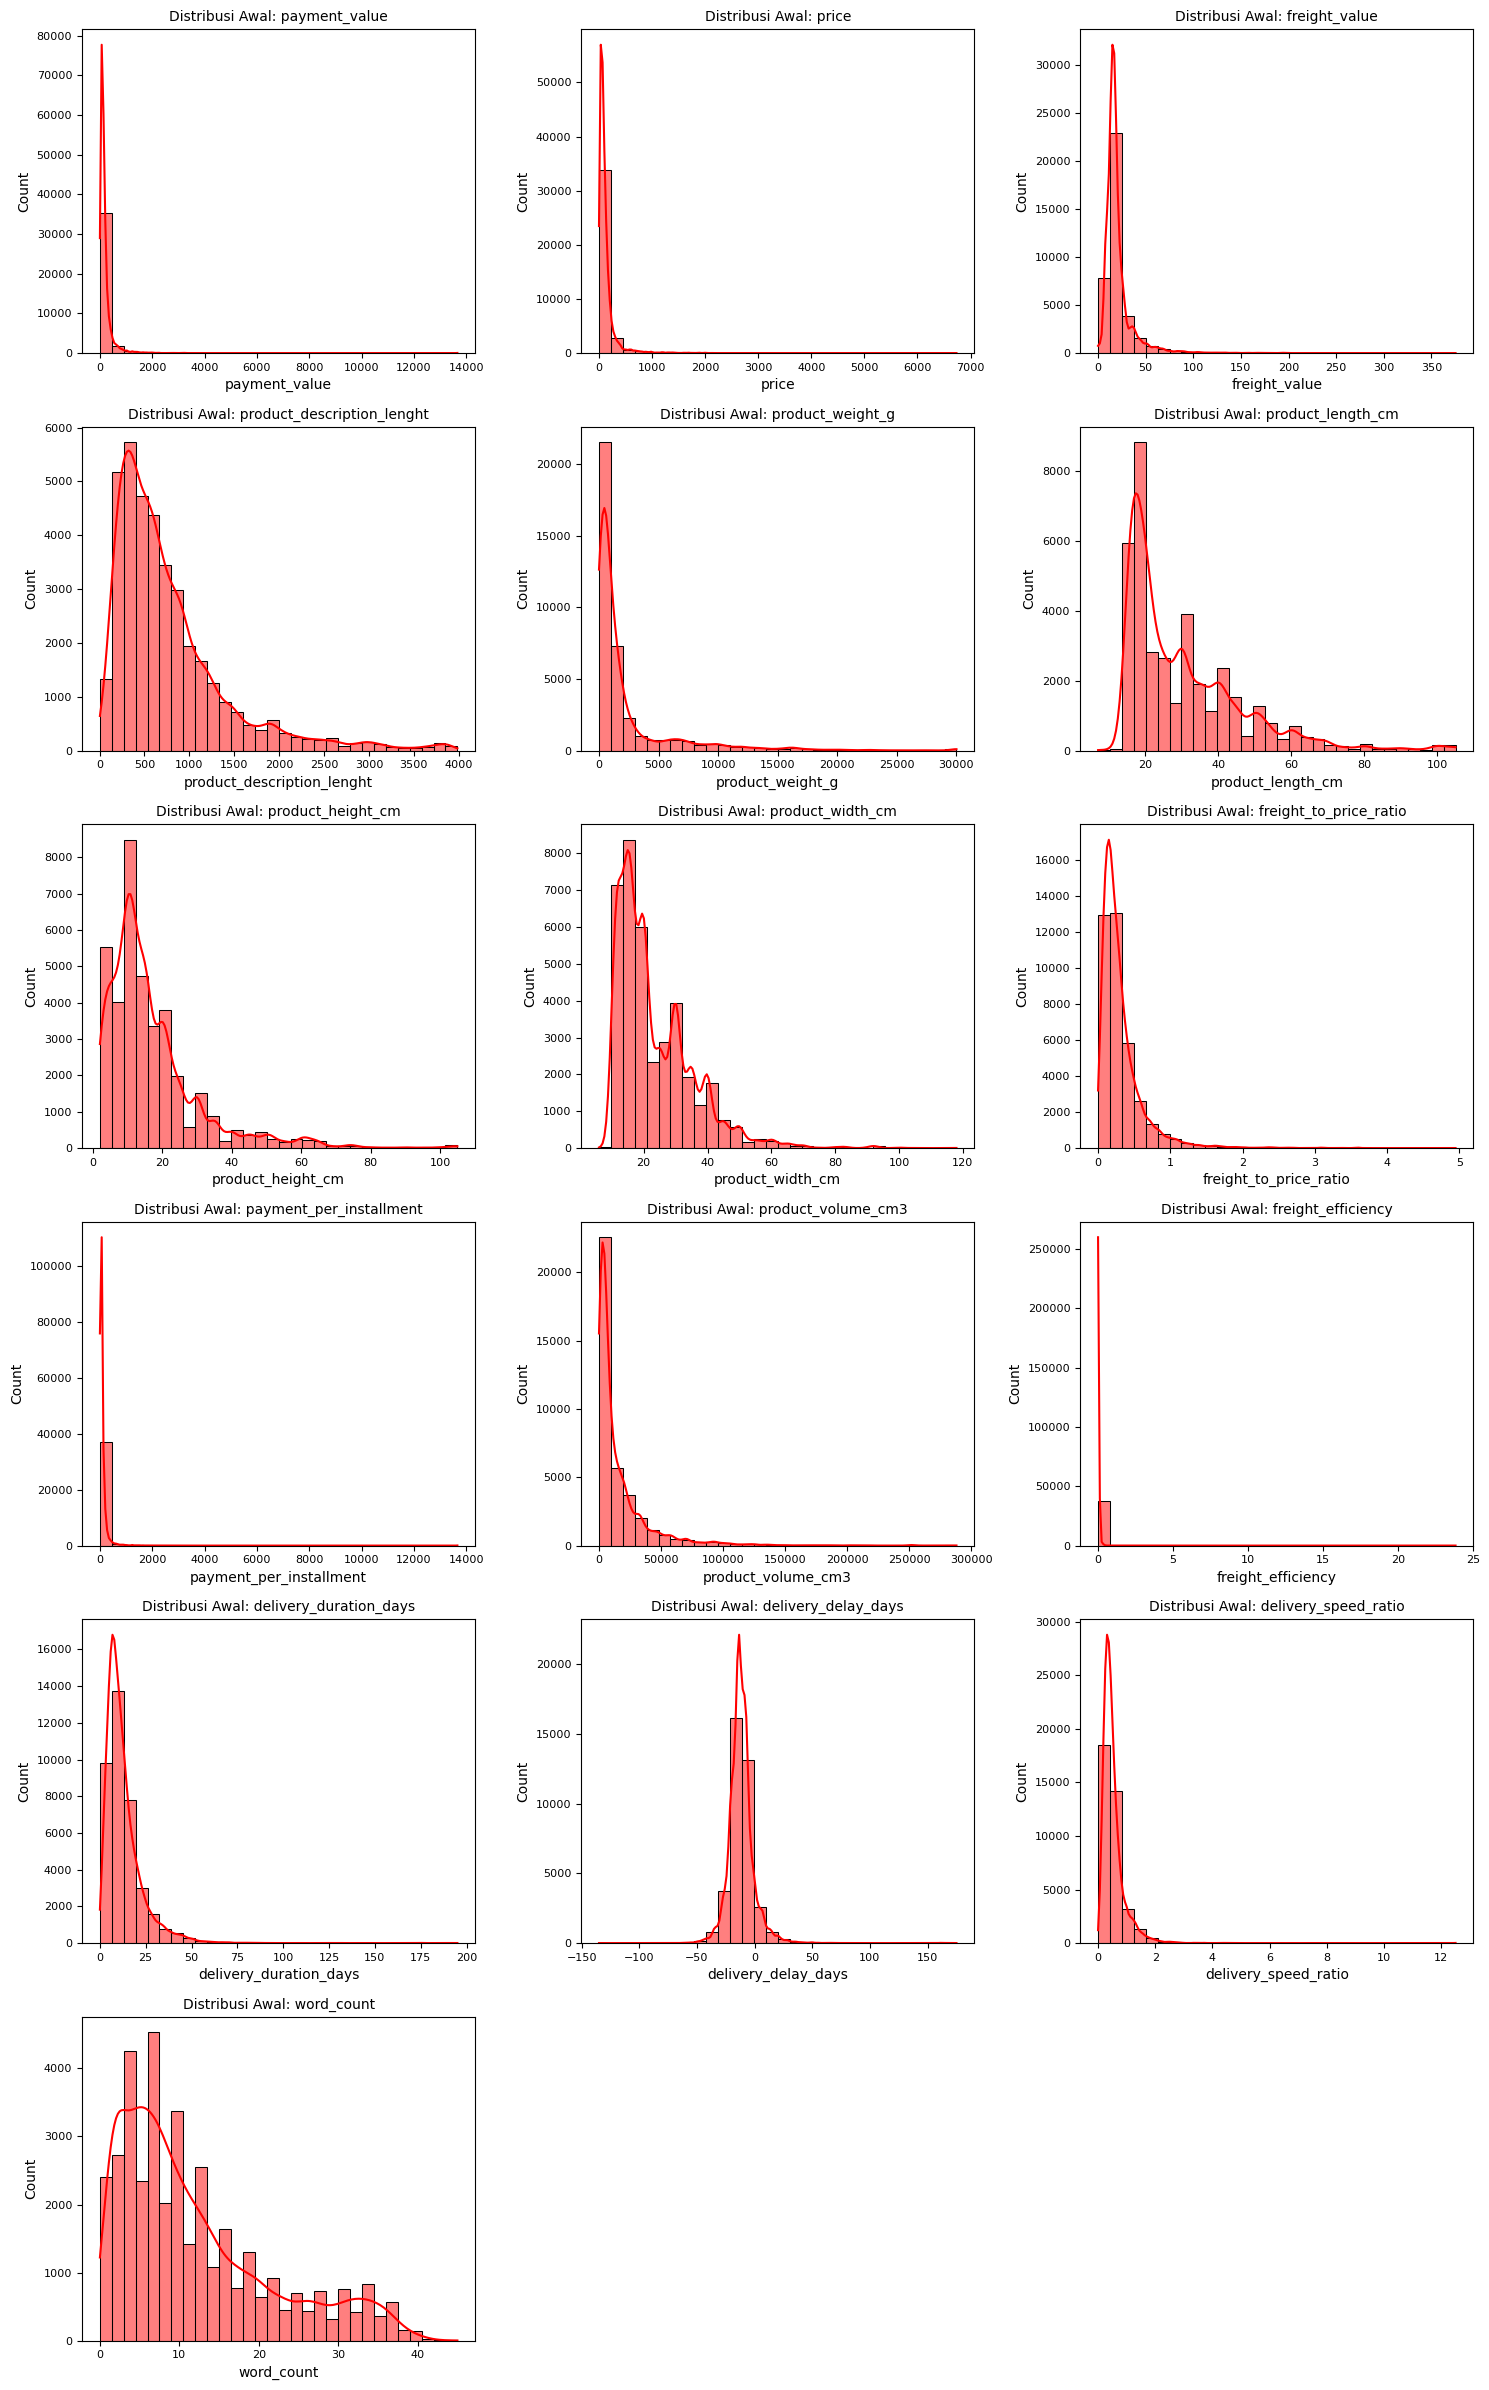

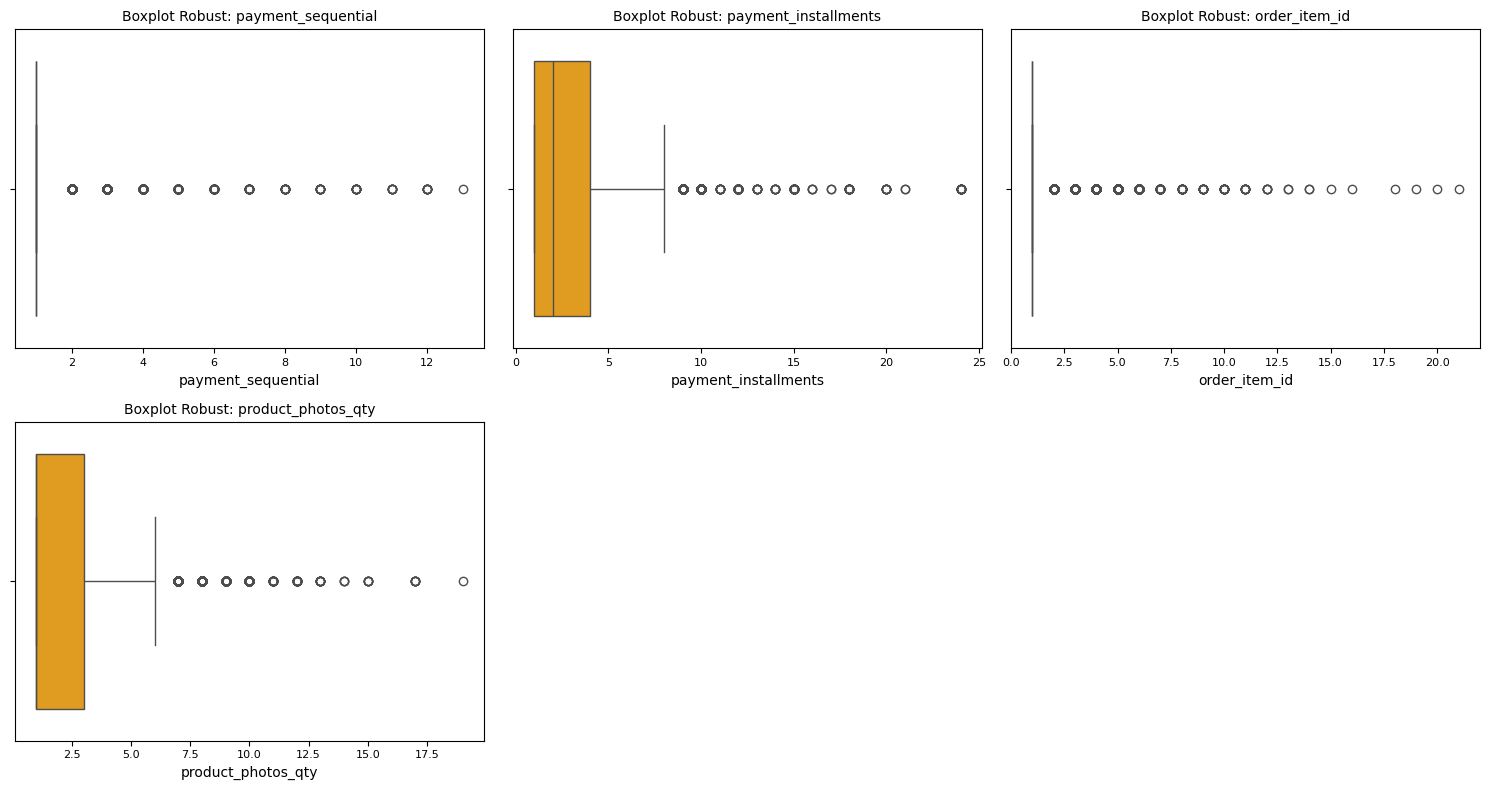

In [11]:
continuous_features = [
    'payment_value', 'price', 'freight_value', 'product_description_lenght',
    'product_weight_g', 'product_length_cm', 'product_height_cm',
    'product_width_cm', 'freight_to_price_ratio', 'payment_per_installment',
    'product_volume_cm3', 'freight_efficiency', 'delivery_duration_days',
    'delivery_delay_days', 'delivery_speed_ratio', 'review_length', 'word_count'
]

discrete_features = [
    'payment_sequential', 'payment_installments', 'order_item_id', 'product_photos_qty'
]

def plot_skewed_distributions(df, features):
    skew_vals = df[features].skew()
    skewed_cols = skew_vals[skew_vals.abs() > 1].index.tolist()
    num_cols = len(skewed_cols)
    n_rows = (num_cols + 2) // 3
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(skewed_cols):
        sns.histplot(df[col], kde=True, ax=axes[i], color='red', bins=30)
        axes[i].set_title(f'Distribusi Awal: {col}', fontsize=10)
        axes[i].tick_params(labelsize=8)
    
    for j in range(len(skewed_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

plot_skewed_distributions(x_train, continuous_features)

def plot_boxplots(df, features):
    num_feats = len(features)
    n_rows = math.ceil(num_feats / 3)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        sns.boxplot(x=df[col], ax=axes[i], color='orange')
        axes[i].set_title(f'Boxplot Robust: {col}', fontsize=10)
        axes[i].tick_params(labelsize=8)
    
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

plot_boxplots(x_train, discrete_features)

## Pipeline

In [12]:
old_text_cols = ['review_comment_message', 'review_comment_title', 'combined_text']
categorical_features = [col for col in x_train.select_dtypes(include=['object']).columns if col not in old_text_cols]
text_feature = 'combined_text'

discrete_pipeline = Pipeline(steps=[('scaler', RobustScaler())])
continuous_pipeline = Pipeline(steps=[('scaler', PowerTransformer(method='yeo-johnson'))])
categorical_pipeline = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
nlp_pipeline = Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2))])

preprocessor = ColumnTransformer(transformers=[
    ('discrete_prep', discrete_pipeline, discrete_features),
    ('continuous_prep', continuous_pipeline, continuous_features),
    ('categorical_prep', categorical_pipeline, categorical_features),
    ('text_prep', nlp_pipeline, text_feature)
])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

x_train_dense = x_train_processed.toarray() if hasattr(x_train_processed, "toarray") else x_train_processed
x_test_dense = x_test_processed.toarray() if hasattr(x_test_processed, "toarray") else x_test_processed

x_train_opt, x_val_opt, y_train_opt, y_val_opt = train_test_split(
    x_train_dense, y_train, test_size=0.2, random_state=42, stratify=y_train
)

## Determining Dataset Linearity: Linear vs. Non-Linear Models

Pengujian ini dilakukan untuk mengidentifikasi apakah karakteristik dataset lebih cocok diproses menggunakan pendekatan linear atau non-linear.

In [13]:
print("\nLogistic Regression (Linear)")
model_linear = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_linear.fit(x_train_opt, y_train_opt)
pred_linear = model_linear.predict(x_val_opt)
f1_linear = f1_score(y_val_opt, pred_linear, average='macro')

print("XGBoost (Non-Linear)")
model_nonlinear = XGBClassifier(random_state=42, eval_metric='mlogloss')
model_nonlinear.fit(x_train_opt, y_train_opt)
pred_nonlinear = model_nonlinear.predict(x_val_opt)
f1_nonlinear = f1_score(y_val_opt, pred_nonlinear, average='macro')

print(f"\nF1 Macro (Linear)     : {f1_linear:.4f}")
print(f"F1 Macro (Non-Linear) : {f1_nonlinear:.4f}")


Logistic Regression (Linear)
XGBoost (Non-Linear)

F1 Macro (Linear)     : 0.6643
F1 Macro (Non-Linear) : 0.6795


Meskipun margin performanya relatif tipis, evaluasi baseline menunjukkan dataset lebih condong berkarakter non-linear. Oleh karena itu, pendekatan pemodelan akan diprioritaskan menggunakan algoritma tree-based untuk menangkap kompleksitas pola yang tidak dapat dipetakan oleh model linear.

## Optuna Level 1

##### Mencari kombinasi parameter terbaik untuk algoritma LightGBM dan XGBoost agar dapat menghasilkan probabilitas prediksi yang optimal.

In [ ]:
def objective_level_1(trial, model_name):
    if model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300), 
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), 
            'max_depth': trial.suggest_int('max_depth', 3, 15)
        }
        model = lgb.LGBMClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
        model.fit(x_train_opt, y_train_opt)
        
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300), 
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), 
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }
        model = xgb.XGBClassifier(**params, random_state=42, n_jobs=-1)
        sample_weights = compute_sample_weight('balanced', y_train_opt)
        model.fit(x_train_opt, y_train_opt, sample_weight=sample_weights)
        
    predictions = model.predict(x_val_opt)
    return f1_score(y_val_opt, predictions, average='macro')

models_to_tune = ['LightGBM', 'XGBoost']
best_level1_models = {}

for model_name in models_to_tune:
    print(f"\n{model_name}")
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_level_1(trial, model_name), n_trials=20) 
    
    print(f"Best Parameter {model_name}: {study.best_params}")
    
    if model_name == 'LightGBM':
        final_model = lgb.LGBMClassifier(**study.best_params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    elif model_name == 'XGBoost':
        final_model = xgb.XGBClassifier(**study.best_params, random_state=42, n_jobs=-1)
        
    best_level1_models[model_name] = final_model

[I 2026-09-04 02:24:12,967] A new study created in memory with name: no-name-b428d902-76d5-40e7-a6e4-0e60624fb2b6



LightGBM


d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-09-04 02:24:19,175] Trial 0 finished with value: 0.6188431326828145 and parameters: {'n_estimators': 149, 'learning_rate': 0.011266224581399236, 'max_depth': 5}. Best is trial 0 with value: 0.6188431326828145.
d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-09-04 02:24:33,774] Trial 1 finished with value: 0.7269478683935207 and parameters: {'n_estimators': 280, 'learning_rate': 0.08242757184604532, 'max_depth': 15}. Best is trial 1 with value: 0.7269478683935207.
d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-09-04 02:24:44,6

Best Parameter LightGBM: {'n_estimators': 299, 'learning_rate': 0.1896225250336176, 'max_depth': 11}

XGBoost


[I 2026-09-04 02:28:06,056] Trial 0 finished with value: 0.7099364057205366 and parameters: {'n_estimators': 91, 'learning_rate': 0.18151311857568128, 'max_depth': 7}. Best is trial 0 with value: 0.7099364057205366.
[I 2026-09-04 02:28:35,700] Trial 1 finished with value: 0.6695140906614713 and parameters: {'n_estimators': 250, 'learning_rate': 0.07063356063055849, 'max_depth': 3}. Best is trial 0 with value: 0.7099364057205366.
[I 2026-09-04 02:29:10,761] Trial 2 finished with value: 0.7177892980958039 and parameters: {'n_estimators': 106, 'learning_rate': 0.16617774987794084, 'max_depth': 9}. Best is trial 2 with value: 0.7177892980958039.
[I 2026-09-04 02:29:53,109] Trial 3 finished with value: 0.7263172552053042 and parameters: {'n_estimators': 196, 'learning_rate': 0.13467563210774455, 'max_depth': 7}. Best is trial 3 with value: 0.7263172552053042.
[I 2026-09-04 02:30:33,415] Trial 4 finished with value: 0.7060711513078891 and parameters: {'n_estimators': 156, 'learning_rate': 0.

Best Parameter XGBoost: {'n_estimators': 129, 'learning_rate': 0.19988242837208314, 'max_depth': 10}


## Stacking Out of Fold (OOF) Level 1

##### Mengekstrak meta-features menggunakan cross val terstratifikasi pada model Level 1 untuk memastikan tidak ada data leakage saat melatih final estimator di Level 2.

In [ ]:
oof_train_lgbm = np.zeros((x_train_dense.shape[0], 3))
oof_train_xgb = np.zeros((x_train_dense.shape[0], 3))

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(x_train_dense, y_train):
    x_tr, x_va = x_train_dense[train_idx], x_train_dense[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    m_lgbm = best_level1_models['LightGBM']
    m_lgbm.fit(x_tr, y_tr)
    oof_train_lgbm[val_idx] = m_lgbm.predict_proba(x_va)
    
    m_xgb = best_level1_models['XGBoost']
    weight_tr = compute_sample_weight('balanced', y_tr)
    m_xgb.fit(x_tr, y_tr, sample_weight=weight_tr)
    oof_train_xgb[val_idx] = m_xgb.predict_proba(x_va)

meta_x_train = np.hstack((oof_train_lgbm, oof_train_xgb))

best_level1_models['LightGBM'].fit(x_train_dense, y_train)
full_weights = compute_sample_weight('balanced', y_train)
best_level1_models['XGBoost'].fit(x_train_dense, y_train, sample_weight=full_weights)

prob_lgbm_test = best_level1_models['LightGBM'].predict_proba(x_test_dense)
prob_xgb_test = best_level1_models['XGBoost'].predict_proba(x_test_dense)
meta_x_test = np.hstack((prob_lgbm_test, prob_xgb_test))

d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Meta Learner Level 2 & Overfitting Check

##### Mengoptimasi parameter regularisasi pada meta-learner Logistic Regression, serta memvalidasi robustness dan metrik performa model pada hold-out test set untuk mendeteksi overfitting.

In [ ]:
def objective_level_2(trial):
    c_param = trial.suggest_float('C', 1e-4, 10.0, log=True)
    
    meta_learner_temp = LogisticRegression(
        C=c_param, class_weight='balanced', max_iter=2000, random_state=42
    )
    
    cv_scores = cross_val_score(
        meta_learner_temp, meta_x_train, y_train, cv=3, scoring='f1_macro', n_jobs=-1
    )
    
    return cv_scores.mean()

study_meta = optuna.create_study(direction='maximize')
study_meta.optimize(objective_level_2, n_trials=50)

print(f"Best C parameter: {study_meta.best_params['C']}")

[I 2026-09-04 02:45:44,745] A new study created in memory with name: no-name-76f03772-7166-4a10-8dd3-ec94d49ca171
[I 2026-09-04 02:45:53,539] Trial 0 finished with value: 0.7264243277115243 and parameters: {'C': 0.00026641101041156634}. Best is trial 0 with value: 0.7264243277115243.
[I 2026-09-04 02:45:59,084] Trial 1 finished with value: 0.7211450214327884 and parameters: {'C': 0.005192761497153186}. Best is trial 0 with value: 0.7264243277115243.
[I 2026-09-04 02:46:04,486] Trial 2 finished with value: 0.7214971792157568 and parameters: {'C': 0.003936023598648964}. Best is trial 0 with value: 0.7264243277115243.
[I 2026-09-04 02:46:09,972] Trial 3 finished with value: 0.7238136534298626 and parameters: {'C': 0.0010900855694816842}. Best is trial 0 with value: 0.7264243277115243.
[I 2026-09-04 02:46:15,477] Trial 4 finished with value: 0.7200267906625865 and parameters: {'C': 1.0689788643570401}. Best is trial 0 with value: 0.7264243277115243.
[I 2026-09-04 02:46:20,700] Trial 5 fini

Best C parameter: 0.00010358134457701481


In [ ]:
best_meta_learner = LogisticRegression(
    C=study_meta.best_params['C'], class_weight='balanced', max_iter=2000, random_state=42
)

best_meta_learner.fit(meta_x_train, y_train)

pred_train = best_meta_learner.predict(meta_x_train)
pred_test = best_meta_learner.predict(meta_x_test)

f1_train_score = f1_score(y_train, pred_train, average='macro')
f1_test_score = f1_score(y_test, pred_test, average='macro')
overfit_gap = abs(f1_train_score - f1_test_score)

print("\nCEK GAP OVERFITTING STACKING (RANDOM SPLIT + OPTUNA LV 2)")
print(f"Skor F1 Macro (Data Train) : {f1_train_score:.4f}")
print(f"Skor F1 Macro (Data Test) : {f1_test_score:.4f}")
print(f"Gap : {overfit_gap:.4f}")

if overfit_gap <= 0.05:
    print("No overfitting.")
elif overfit_gap <= 0.10:
    print("Normal.")
else:
    print("Overfitting")

print(classification_report(y_test, pred_test, target_names=['0 (Kecewa: 1-2)', '1 (Netral: 3)', '2 (Puas: 4-5)']))


CEK GAP OVERFITTING STACKING (RANDOM SPLIT + OPTUNA LV 2)
Skor F1 Macro (Data Train) : 0.7289
Skor F1 Macro (Data Test) : 0.7455
Gap : 0.0167
No overfitting.
                 precision    recall  f1-score   support

0 (Kecewa: 1-2)       0.85      0.87      0.86      2568
  1 (Netral: 3)       0.38      0.57      0.46       872
  2 (Puas: 4-5)       0.96      0.88      0.92      6034

       accuracy                           0.85      9474
      macro avg       0.73      0.77      0.75      9474
   weighted avg       0.88      0.85      0.86      9474



## Meta-Learner Weight Analysis

##### Menganalisis koefisien dari regresi logistik (meta-learner) untuk mengukur tingkat kepentingan (feature importance) atau bobot kontribusi dari masing-masing base estimator (LightGBM dan XGBoost) terhadap keputusan akhir.

In [ ]:
meta_weights = np.abs(best_meta_learner.coef_)
mean_weights = np.mean(meta_weights, axis=0)

score_lgbm = np.sum(mean_weights[0:3])
score_xgb = np.sum(mean_weights[3:6])
total_score = score_lgbm + score_xgb

pct_lgbm = (score_lgbm / total_score) * 100
pct_xgb = (score_xgb / total_score) * 100

df_stacking_weights = pd.DataFrame({
    'Base Estimator (Level 1)': ['LightGBM', 'XGBoost'],
    'Meta-Learner Weight Importance (%)': [pct_lgbm, pct_xgb]
})

df_stacking_weights = df_stacking_weights.sort_values(by='Meta-Learner Weight Importance (%)', ascending=False).reset_index(drop=True)

print(df_stacking_weights)

  Base Estimator (Level 1)  Meta-Learner Weight Importance (%)
0                 LightGBM                           52.524216
1                  XGBoost                           47.475784


# Conclusion

## Kelayakan Model

Sistem **Machine Learning** yang telah dirakit ini berada dalam kondisi **layak untuk langsung di-deploy (Production-Ready)** ke dalam lingkungan operasional.

Penilaian kelayakan ini bertumpu pada ketajaman performa di **dua kelas bisnis paling krusial**, yaitu pelanggan kecewa dan pelanggan puas.

### 1. Deteksi Pelanggan Kecewa
**Detractors / Bintang 1–2**

- **Recall:** 87%–88%
- **Precision:** 85%–86%

Model memiliki tingkat daya tangkap yang tinggi terhadap pelanggan yang berpotensi kecewa. Dengan Recall sebesar **87%–88%**, hampir **9 dari 10 keluhan kritis** dapat terdeteksi secara otomatis.

Hal ini menjadikan model sebagai instrumen **pencegahan churn** yang efektif, sehingga intervensi terhadap pelanggan dapat segera dilakukan sebelum masalah berkembang lebih besar.

### 2. Deteksi Pelanggan Puas
**Promoters / Bintang 4–5**

- **Precision:** 96%
- **Recall:** 88%–89%

Pola kepuasan pelanggan berhasil dipetakan dengan sangat baik. Tingkat Precision yang mencapai **96%** menunjukkan bahwa prediksi pelanggan puas memiliki tingkat ketepatan yang sangat tinggi.

Hasil ini dapat membantu perusahaan dalam mengidentifikasi serta mempertahankan **layanan atau produk yang memiliki performa baik**.

### Kesimpulan

Secara keseluruhan, proses **kalibrasi akhir menggunakan algoritma Optuna** pada arsitektur **Stacking** menghasilkan fondasi prediksi yang solid dengan:

> **Akurasi global: 85%–86%**

Dengan kombinasi performa tersebut, model dinilai **layak untuk diterapkan pada lingkungan operasional (Production-Ready)**.

----

## Sekuritas terhadap Data Leakage dan Overfitting

Untuk memastikan model mampu melakukan generalisasi dengan baik, proses pengembangan model dirancang dengan mempertimbangkan risiko **Data Leakage** dan **Overfitting**.

### 1. Pemberantasan Data Leakage

Desain fitur secara sengaja **mengecualikan variabel waktu mentah**, seperti **Tahun** dan **Bulan transaksi**, untuk menghindari risiko *Concept Drift*.

Dengan demikian, model diarahkan untuk berfokus pada:

- **Pola semantik teks ulasan**
- **Metrik logistik operasional**
- **Karakteristik pelanggan yang relevan**

Model tidak diarahkan untuk sekadar **menghafal waktu atau tanggal kejadian**, sehingga pola yang dipelajari diharapkan lebih relevan ketika diterapkan pada data baru.

### 2. Imunitas terhadap Overfitting

Untuk mengurangi risiko *overfitting*, digunakan beberapa strategi validasi:

- **Random Split** dengan proporsi data yang seimbang (*Stratified*)
- **Out-of-Fold (OOF) Prediction** pada Level 1
- Evaluasi performa menggunakan data yang tidak digunakan secara langsung untuk pembelajaran model

Strategi **OOF** pada arsitektur *Stacking* membantu memastikan bahwa model pada Level 1 menghasilkan prediksi berdasarkan data yang benar-benar **out-of-sample**, sehingga evaluasi menjadi lebih objektif.

### 3. Bukti Validasi

Hasil validasi menunjukkan bahwa selisih (*Gap*) skor **F1-Score** antara data Latih dan data Uji berhasil ditekan pada kisaran:

> **F1 Gap: 0.014–0.016**  
> **≈ 1.5%**

Nilai tersebut berada jauh di bawah **batas toleransi 5%** yang digunakan sebagai indikator risiko overfitting.

### Kesimpulan

Rendahnya *gap* antara performa Latih dan Uji menunjukkan bahwa model memiliki **generalisasi yang baik** dan tidak menunjukkan indikasi overfitting yang signifikan.

Dengan desain fitur yang menghindari potensi **Data Leakage** serta validasi berbasis **Stratified Split dan OOF**, model memiliki fondasi yang lebih kuat untuk memproses **teks pelanggan baru di lingkungan dunia nyata**.

---

## Tantangan Teknis

Dalam proses pengembangan sistem, terdapat beberapa tantangan teknis utama yang perlu ditangani, terutama berkaitan dengan **ketersediaan data teks**, **ambiguitas kelas Netral**, dan **ketidakseimbangan distribusi kelas**.

### 1. Krisis Teks: 58% Data Kosong

Sistem **Natural Language Processing (NLP)** membutuhkan informasi tekstual sebagai sumber utama dalam melakukan analisis. Namun, lebih dari **58% data ulasan tidak memiliki teks** dan hanya berisi rating.

Kondisi tersebut menjadi tantangan karena model NLP kehilangan informasi semantik yang dibutuhkan untuk memahami sentimen pelanggan. Akibatnya, model berpotensi melakukan prediksi hanya berdasarkan fitur numerik, seperti **rating dan ongkos kirim**, tanpa memahami alasan di balik penilaian pelanggan.

Untuk mengatasi permasalahan tersebut, diterapkan strategi:

- Menggabungkan **Judul** dan **Isi Pesan** menjadi satu sumber teks.
- Mengidentifikasi data yang benar-benar tidak memiliki informasi tekstual.
- Membuang data yang **sepenuhnya hampa teks** agar tidak memberikan sinyal yang menyesatkan kepada model.

Strategi tersebut terbukti krusial dalam meningkatkan kualitas informasi yang tersedia bagi model dan mengembalikan rasionalitas dalam proses prediksi.

### 2. Ambiguitas Kelas Netral: Bintang 3

Kelas **Netral (Bintang 3)** menjadi salah satu tantangan terbesar karena memiliki karakteristik yang lebih ambigu dibandingkan kelas lainnya.

Beberapa pola yang ditemukan antara lain:

- **Sinyal kontradiktif**, seperti pelanggan memuji kualitas barang tetapi sekaligus mengeluhkan kinerja kurir dalam satu ulasan.
- **Teks yang sangat pendek**, seperti `"ok"` atau `"standar"`.
- **Minimnya kata-kata emosional**, sehingga sulit menentukan apakah pelanggan sebenarnya sedikit kecewa, benar-benar netral, atau cukup puas.

Kondisi tersebut menyebabkan metode berbasis penghitung kata seperti **TF-IDF** mengalami kesulitan dalam menentukan batas antara kelas yang berdekatan.

### 3. Ketidakseimbangan Distribusi Kelas (*Data Imbalance*)

Tantangan fundamental lainnya adalah **proporsi jumlah data antar kelas sentimen yang sangat timpang**.

Distribusi kelas menunjukkan bahwa:

- **Puas (Bintang 4–5)** mendominasi dataset secara absolut.
- **Kecewa (Bintang 1–2)** berada di posisi menengah.
- **Netral (Bintang 3)** menjadi kelas dengan jumlah data paling sedikit.

Kondisi tersebut berisiko menyebabkan algoritma membangun **bias terhadap kelas mayoritas**. Model dapat cenderung mengabaikan kelas minoritas dan lebih sering memprediksi kelas mayoritas hanya untuk memperoleh akurasi global yang tinggi.

Akibatnya, akurasi dapat memberikan gambaran performa yang menyesatkan atau menciptakan **ilusi akurasi**, karena performa pada kelas minoritas tidak tercermin secara proporsional.

Untuk mengatasi ketimpangan tersebut, diterapkan beberapa langkah teknis:

- Menggunakan **F1 Macro** sebagai acuan utama evaluasi agar performa setiap kelas, termasuk kelas minoritas, diperhitungkan secara lebih adil dan setara.
- Menerapkan parameter penyeimbang bobot kelas **`class_weight='balanced'`** pada algoritma yang mendukungnya, sehingga kesalahan pada kelas minoritas mendapatkan penalti yang lebih besar.
- Menggunakan metode pembagian data berjenjang **(*Stratified Split*)** untuk menjaga proporsi ketiga kelas tetap konsisten pada fase pelatihan maupun pengujian.

Pendekatan tersebut membantu model untuk tidak hanya mengejar performa pada kelas mayoritas, tetapi juga mempertahankan kemampuan prediksi terhadap kelas minoritas.

### Kesimpulan

Tantangan utama sistem tidak hanya berasal dari algoritma, tetapi juga dari **kualitas, ketersediaan, dan distribusi data**.

Tiga permasalahan utama yang berhasil diidentifikasi adalah:

1. **Krisis data teks**, dengan lebih dari 58% ulasan tidak memiliki teks.
2. **Ambiguitas kelas Netral**, terutama pada ulasan pendek dan memiliki sinyal sentimen yang tidak jelas.
3. **Ketidakseimbangan distribusi kelas**, dengan dominasi kelas Puas dan jumlah kelas Netral yang jauh lebih sedikit.

Penanganan ketiga permasalahan tersebut menjadi faktor penting agar model tidak hanya memiliki performa statistik yang baik, tetapi juga mampu menghasilkan prediksi yang **rasional, seimbang, dan relevan terhadap konteks pelanggan**.

---

## Strategi di Masa Depan

Untuk meningkatkan kualitas, ketahanan, dan kemampuan adaptasi sistem dalam jangka panjang, terdapat beberapa strategi pengembangan yang dapat diterapkan pada tahap selanjutnya.

### 1. Optimalisasi Pengumpulan Data (*Data Collection*)

Sangat disarankan untuk menerapkan aturan **wajib isi ulasan dengan minimal 10 karakter** pada antarmuka aplikasi, khususnya bagi pelanggan yang memberikan **rating Bintang 3**.

Masukan teks yang lebih informatif akan memberikan bahan baku kosakata yang jauh lebih kaya bagi model. Dengan semakin banyaknya data tekstual yang relevan, model diharapkan dapat:

- Mengenali karakteristik bahasa pada kelas Netral dengan lebih baik.
- Membedakan pelanggan yang benar-benar netral dari pelanggan yang sedikit kecewa atau puas.
- Mengurangi ambiguitas yang selama ini menjadi tantangan utama pada **kelas Bintang 3**.

### 2. Pelatihan Ulang Berkala (*Continuous Retraining*)

Kosakata pelanggan, tren keluhan, serta pola permasalahan operasional dapat terus berubah seiring waktu. Oleh karena itu, model perlu mendapatkan pembaruan secara berkala.

Arsitektur ini disarankan untuk menjalani proses **retraining setiap 3–6 bulan** menggunakan basis data terbaru.

Proses tersebut bertujuan untuk:

- Memperbarui kamus **TF-IDF** dengan kosakata terbaru.
- Menyesuaikan model terhadap penggunaan bahasa slang atau istilah baru.
- Mengakomodasi perubahan pola keluhan pelanggan.
- Menyesuaikan model dengan konteks kendala operasional yang sedang berkembang.

Dengan pendekatan ini, model tidak hanya mengandalkan pola bahasa dari data historis, tetapi dapat terus beradaptasi terhadap karakteristik data terbaru.

### 3. Evolusi ke Deep Learning (*Transformer*)

Pada tahap pengembangan selanjutnya, sistem dapat dievolusikan dari pendekatan berbasis **TF-IDF** menuju arsitektur **Deep Learning**, khususnya model berbasis *Transformer* seperti **BERT** atau **RoBERTa**.

Dengan dukungan **GPU**, model Transformer dapat memproses hubungan antar-kata dalam konteks kalimat secara lebih mendalam. Berbeda dengan TF-IDF yang terutama merepresentasikan pentingnya kata berdasarkan frekuensi kemunculannya, Transformer mampu mempertimbangkan **konteks dan hubungan antar-token dalam suatu kalimat**.

Pengembangan ini berpotensi meningkatkan kemampuan model dalam menangani:

- Sarkasme dan ungkapan tidak langsung.
- Kalimat dengan konteks ganda.
- Sinyal sentimen yang saling bertentangan.
- Ambiguitas linguistik tingkat tinggi.
- Hubungan antar-kata yang bergantung pada konteks kalimat.

### Kesimpulan

Pengembangan sistem ke depan dapat difokuskan pada tiga aspek utama:

1. **Meningkatkan kualitas data** melalui pengumpulan ulasan yang lebih informatif.
2. **Menjaga relevansi model** melalui proses *Continuous Retraining* secara berkala.
3. **Meningkatkan kemampuan pemahaman bahasa** melalui transisi menuju arsitektur Transformer.

Ketiga strategi tersebut diharapkan dapat meningkatkan kemampuan sistem dalam menghadapi perubahan karakteristik pelanggan sekaligus mengatasi keterbatasan pendekatan NLP berbasis **TF-IDF**.